## Data Analysis Python Project

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import Raw Data

In [3]:
df = pd.read_csv("blinkit_data.csv")

### Sample Data

In [4]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.1,145.4786,5.0


### Dataset Size

In [5]:
print("Size of data",df.shape)

Size of data (8523, 12)


### Field info

In [6]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

### Field Data types

In [7]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### Data Cleaning

In [8]:
df["Item Fat Content"] = df["Item Fat Content"].replace({'LF':'Low Fat', 'low fat':'Low Fat', 'reg':'Regular'})

In [9]:
df["Item Fat Content"].unique()

array(['Regular', 'Low Fat'], dtype=object)

### Business Requirements

#### KPI Requirements

In [12]:
#Total Sales
total_sales = df['Sales'].sum()

#Average Sales
avg_sales = df['Sales'].mean()

#Transactions
transaction = df['Sales'].count()

#Average Customer Rating
avg_rating = df['Rating'].mean()

#Display

print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${avg_sales:,.1f}")
print(f"Total Transactions: {transaction:,.0f}")
print(f"Customer Average Rating: {avg_rating:,.1f}")

Total Sales: $1,201,681
Average Sales: $141.0
Total Transactions: 8,523
Customer Average Rating: 4.0


### **Charts Requirments**

#### **Total Sales by Fat Content**

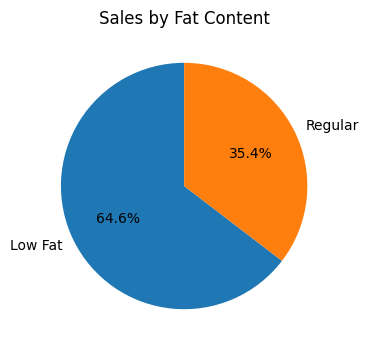

In [89]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
plt.figure(figsize = [4,4])
plt.pie(sales_by_fat, labels = sales_by_fat.index, autopct = '%1.1f%%', startangle = 90)
plt.title("Sales by Fat Content")
plt.show()

#### **Total Sales by Item Type**

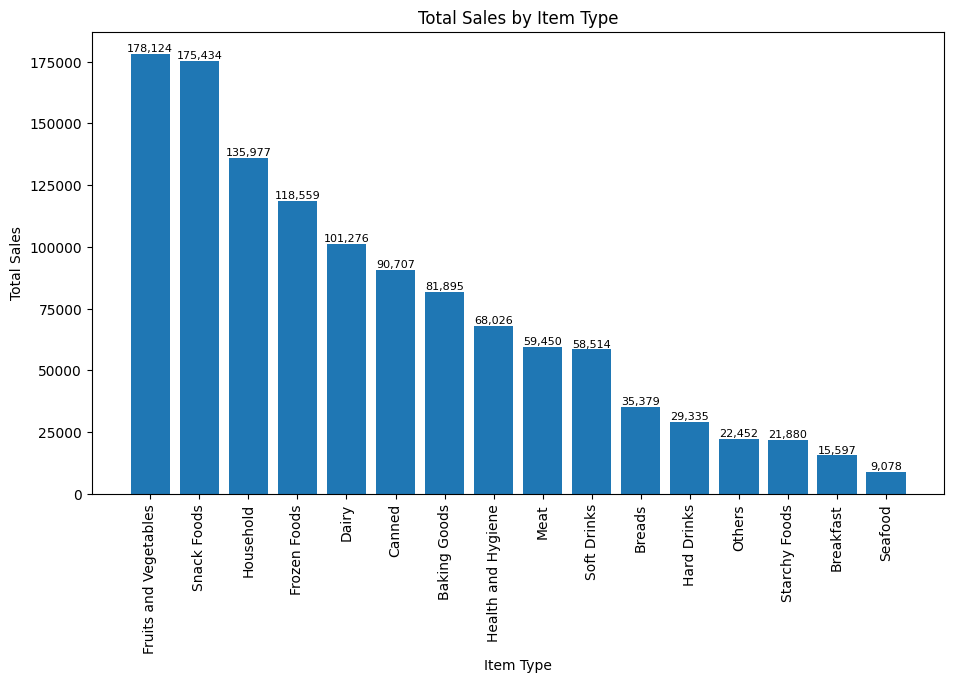

In [100]:
Sales_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending = False)

plt.figure(figsize = [11,6])
bars = plt.bar(Sales_type.index, Sales_type.values)

plt.xticks(rotation = 90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha = 'center', va = 'bottom', fontsize = 8)

plt.show()

#### **Fat Content by Outlet for Total Sales**

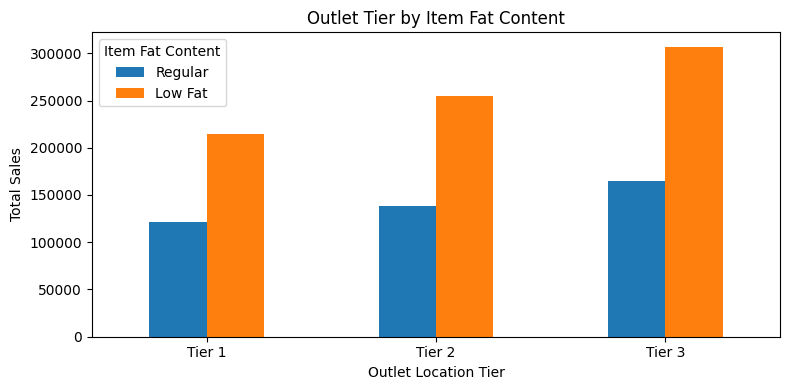

In [86]:
grouped = df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]

ax = grouped.plot(kind = 'bar', figsize=[8,4], title = 'Outlet Tier by Item Fat Content', xlabel = 'Outlet Location Tier', ylabel = 'Total Sales')
plt.xticks(rotation = 0)
plt.legend(title = 'Item Fat Content')
plt.tight_layout()
plt.show()

#### **Total Sales by Outlet Establishment**

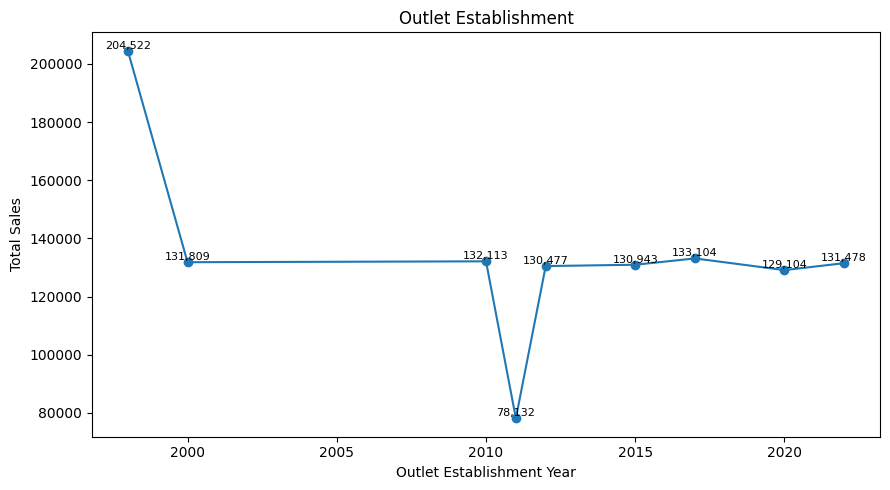

In [97]:
Sales_Year = df.groupby('Outlet Establishment Year')['Sales'].sum()

plt.figure(figsize = [9,5])
plt.plot(Sales_Year.index, Sales_Year.values, 'o-')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(Sales_Year.index, Sales_Year.values):
    plt.text(x,y, f'{y:,.0f}', ha = 'center', va = 'bottom', fontsize = 8)

plt.tight_layout()
plt.show()

#### **Total Sales by Outlet Size**

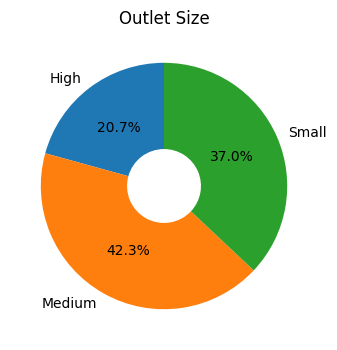

In [130]:
sales_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize = [4,4])
plt.pie(sales_size.values, labels = sales_size.index, autopct = '%1.1f%%', startangle = 90,wedgeprops={'width':0.7})
plt.title('Outlet Size')
plt.show()

#### **Total Sales by Location**

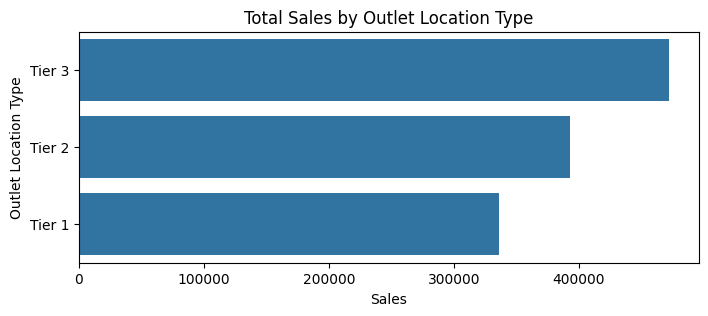

In [114]:
Sales_location = df.groupby('Outlet Location Type')['Sales'].sum().sort_values(ascending = False).reset_index()
plt.figure(figsize = [8,3])

ax = sns.barplot(x = 'Sales', y = 'Outlet Location Type', data = Sales_location)
plt.title('Total Sales by Outlet Location Type')
plt.show()